Ba-Spektrum Links und Rechts

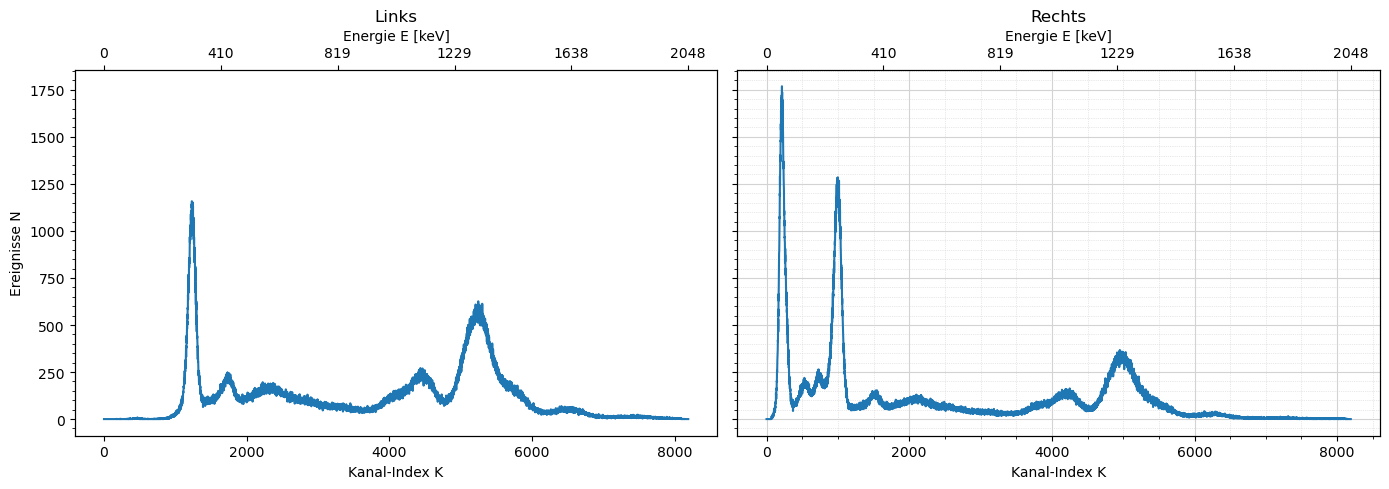

In [92]:
import numpy as np
import matplotlib.pyplot as plt

def load_mca_file(filename):
    """
    Lädt eine 2-Spalten-MCA-Datei:
    Kanalindex   Ereignisse
    Falls Zeilen fehlen oder nur eine Spalte existiert,
    wird das automatisch korrigiert.
    """
    raw = np.loadtxt(filename, dtype=float)

    # Falls nur eine Zeile vorhanden ist → 2D machen
    if raw.ndim == 1:
        raw = raw.reshape(1, -1)

    # Falls nur eine Spalte existiert → zweite Spalte = 0
    if raw.shape[1] == 1:
        K = np.arange(len(raw))
        N = raw[:, 0]
    else:
        K = raw[:, 0].astype(int)
        N = raw[:, 1]

    # Falls Kanäle fehlen → auf volle Länge auffüllen
    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full


# ---------------------------------------------------------
# Dateien laden
# ---------------------------------------------------------

K_left, N_left = load_mca_file("Balinkscfd.txt")
K_right, N_right = load_mca_file("Barechtscfd.txt")

# ---------------------------------------------------------
# Energie-Kalibration (Beispielwerte)
# ---------------------------------------------------------

a = 0.25  # keV pro Kanal
b = 0.0

E_left  = a * K_left  + b
E_right = a * K_right + b

# ---------------------------------------------------------
# Plot erstellen
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plt.minorticks_on()

# 2. Style both major and minor grids (making minor lines thinner/lighter)
plt.grid(which='major', color='lightgray', linestyle='-', linewidth=0.8)
plt.grid(which='minor', color='lightgray', linestyle=':', linewidth=0.5)

# --- Links ---
axes[0].plot(K_left, N_left, color='tab:blue')
axes[0].set_title("Links")
axes[0].set_xlabel("Kanal-Index K")
axes[0].set_ylabel("Ereignisse N")

ax2_left = axes[0].twiny()
ax2_left.set_xlim(axes[0].get_xlim())
ticks = np.linspace(K_left.min(), K_left.max(), 6)
ax2_left.set_xticks(ticks)
ax2_left.set_xticklabels([f"{a*k+b:.0f}" for k in ticks])
ax2_left.set_xlabel("Energie E [keV]")

# --- Rechts ---


axes[1].plot(K_right, N_right, color='tab:blue')
axes[1].set_title("Rechts")
axes[1].set_xlabel("Kanal-Index K")

ax2_right = axes[1].twiny()
ax2_right.set_xlim(axes[1].get_xlim())
ticks = np.linspace(K_right.min(), K_right.max(), 6)
ax2_right.set_xticks(ticks)
ax2_right.set_xticklabels([f"{a*k+b:.0f}" for k in ticks])
ax2_right.set_xlabel("Energie E [keV]")

plt.tight_layout()
plt.show()


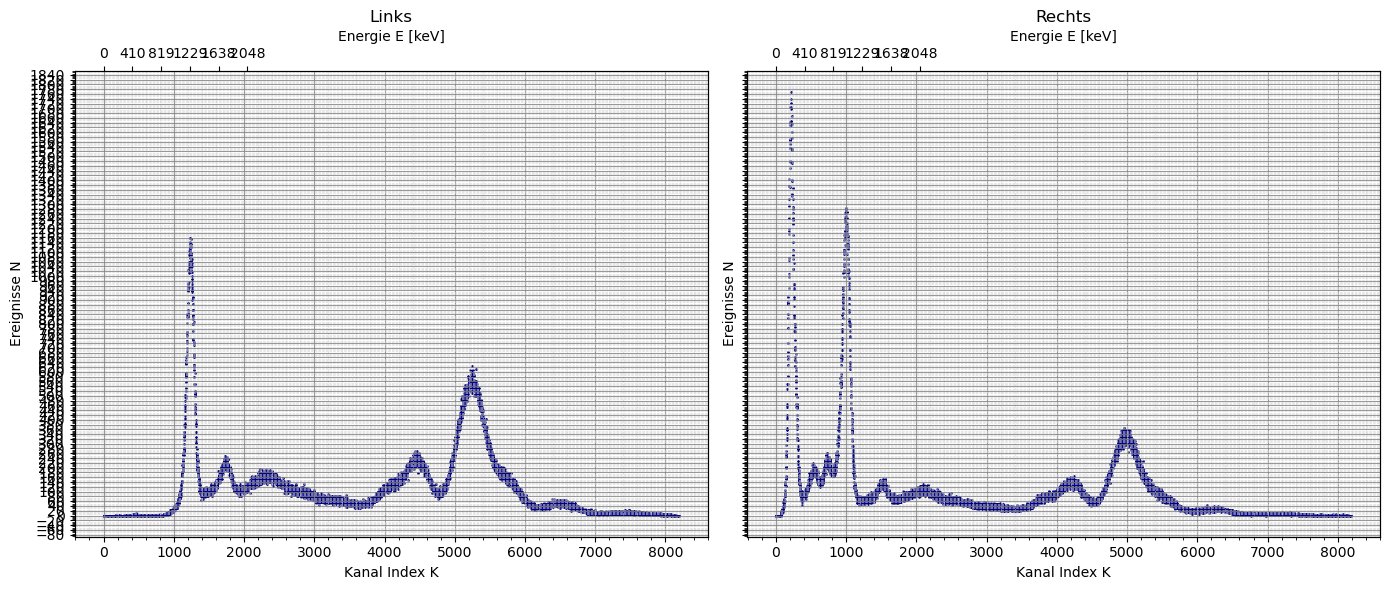

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Beispiel: Daten laden

K_L, N_L = load_mca_file("Balinkscfd.txt")
K_R, N_R = load_mca_file("Barechtscfd.txt")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ---------------------------------------------------------
# Funktion zum Stylen eines Plots
# ---------------------------------------------------------
def style_plot(ax, K, N, title=""):
    ax.scatter(K, N, s=1, color="navy")

    # Achsenbeschriftung
    ax.set_xlabel("Kanal Index K")
    ax.set_ylabel("Ereignisse N")

    # Gitter: Major + Minor
    ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(200))

    ax.grid(True, which="major", axis="both",
            linestyle="-", linewidth=0.8, color="gray", alpha=0.8)

    ax.grid(True, which="minor", axis="both",
            linestyle="--", linewidth=0.5, color="lightgray", alpha=0.8)

    # Obere Energie-Achse
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())

    # Beispiel-Energieticks
    ticks = np.array([0, 410, 819, 1229, 1638, 2048])
    ax2.set_xticks(ticks)
    ax2.set_xticklabels([str(t) for t in ticks])
    ax2.set_xlabel("Energie E [keV]")

    ax.set_title(title)


# ---------------------------------------------------------
# Linker Plot
# ---------------------------------------------------------
style_plot(axL, K_L, N_L, title="Links")

# ---------------------------------------------------------
# Rechter Plot
# ---------------------------------------------------------
style_plot(axR, K_R, N_R, title="Rechts")

plt.tight_layout()
plt.show()


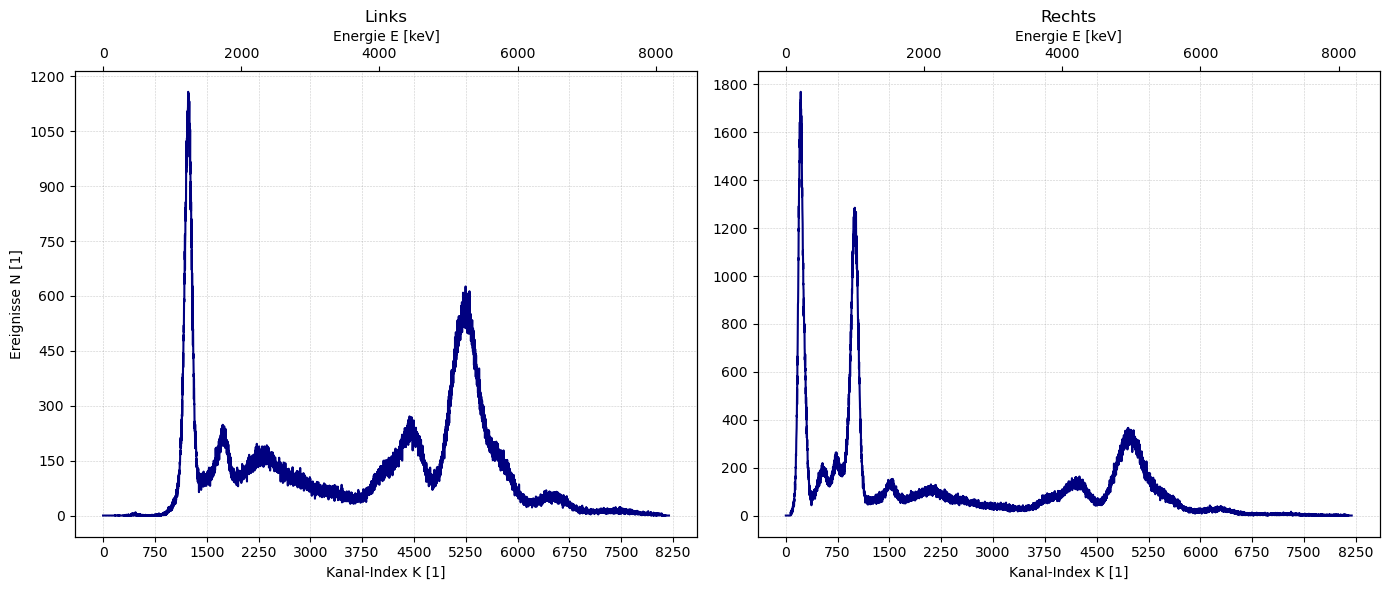

In [108]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# --- Linker Plot ---
axL.plot(K_L, N_L, color="navy")
axL.set_title("Links")
axL.set_xlabel("Kanal-Index K [1]")
axL.set_ylabel("Ereignisse N [1]")

# großes, dezentes Gitter
axL.xaxis.set_major_locator(ticker.MultipleLocator(750))
axL.yaxis.set_major_locator(ticker.MultipleLocator(150))
axL.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.4)

# obere Achse
ax2L = axL.twiny()
ax2L.set_xlim(axL.get_xlim())
ax2L.set_xlabel("Energie E [keV]")

# --- Rechter Plot ---
axR.plot(K_R, N_R, color="navy")
axR.set_title("Rechts")
axR.set_xlabel("Kanal-Index K [1]")

# anderes Y‑Gitter (weil andere Skala)
axR.xaxis.set_major_locator(ticker.MultipleLocator(750))
axR.yaxis.set_major_locator(ticker.MultipleLocator(200))   # z.B. 400 statt 500
axR.grid(True, which="major", linestyle="--", linewidth=0.4, color="gray", alpha=0.4)

# obere Achse
ax2R = axR.twiny()
ax2R.set_xlim(axR.get_xlim())
ax2R.set_xlabel("Energie E [keV]")

plt.tight_layout()
plt.savefig("Ba_links_rechts_fast.png", dpi=300)
plt.show()



Promptkurve Na am MCA

In [12]:
import os
print(os.getcwd())
import os
files = [
    "Nalinksprompt.txt",
    "Narechtspromp.txt"
]

def load_mca_file(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Datei nicht gefunden: {filename}\n"
            f"Aktueller Ordner: {os.getcwd()}\n"
            f"Gefundene Dateien: {os.listdir()}"
        )
    return np.loadtxt(filename)
print(load_mca_file(files[0]))
print(load_mca_file(files[1]))

/home/s6norupp/physik/p5_2026/v525/code


FileNotFoundError: Datei nicht gefunden: Nalinksprompt.txt
Aktueller Ordner: /home/s6norupp/physik/p5_2026/v525/code
Gefundene Dateien: ['Barechtscfd.txt', 'Narechtsprom.txt', 'Nalinkspromt.txt', 'Auswertung.ipynb', 'Balinkscfd.txt']

/tmp/ipykernel_950072/3193473452.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


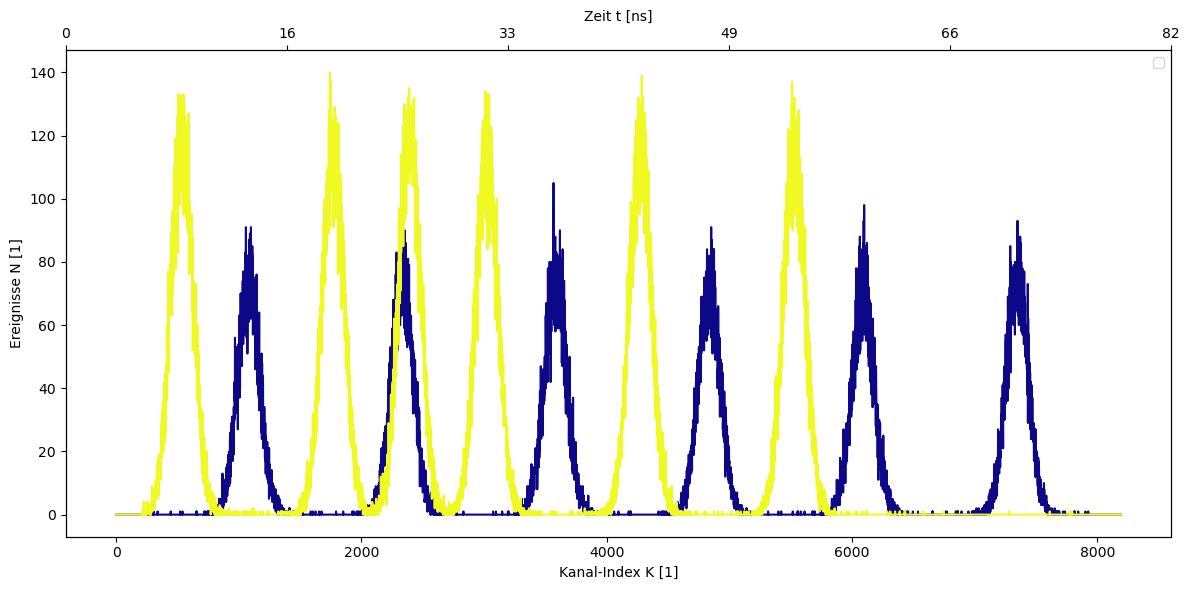

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Loader für deine MCA-Dateien
# ---------------------------------------------------------
def load_mca_file(filename):
    """
    Lädt eine 2-Spalten-MCA-Datei:
    Kanalindex   Ereignisse
    Falls Zeilen fehlen oder nur eine Spalte existiert,
    wird das automatisch korrigiert.
    """
    raw = np.loadtxt(filename, dtype=float)

    # Falls nur eine Zeile vorhanden ist → 2D machen
    if raw.ndim == 1:
        raw = raw.reshape(1, -1)

    # Falls nur eine Spalte existiert → zweite Spalte = 0
    if raw.shape[1] == 1:
        K = np.arange(len(raw))
        N = raw[:, 0]
    else:
        K = raw[:, 0].astype(int)
        N = raw[:, 1]

    # Falls Kanäle fehlen → auf volle Länge auffüllen
    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full


# ---------------------------------------------------------
# Dateien laden
# ---------------------------------------------------------
files = [
    "Nalinkspromt.txt",
    "Narechtsprom.txt"
]

spectra = [load_mca_file(f) for f in files]

# ---------------------------------------------------------
# Zeitkalibration (Beispielwerte)
# ---------------------------------------------------------
# Falls dein TAC z.B. 0–100 ns auf 0–10000 Kanäle abbildet:
a = 0.01   # ns pro Kanal
b = 0.0    # Offset

# ---------------------------------------------------------
# Plot erstellen
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

colors = plt.cm.plasma(np.linspace(0, 1, len(spectra)))

for (K, N), color, fname in zip(spectra, colors, files):
    t = a * K + b
    plt.plot(K, N, color=color, label=f"{fname}")

# Achsenbeschriftungen
plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")

# Zweite x-Achse für Zeit
ax2 = plt.gca().twiny()
ax2.set_xlim(plt.gca().get_xlim())
ticks = np.linspace(K.min(), K.max(), 6)
ax2.set_xticks(ticks)
ax2.set_xticklabels([f"{a*k+b:.0f}" for k in ticks])
ax2.set_xlabel("Zeit t [ns]")

plt.legend()
plt.tight_layout()
plt.show()



/tmp/ipykernel_950072/3123346175.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


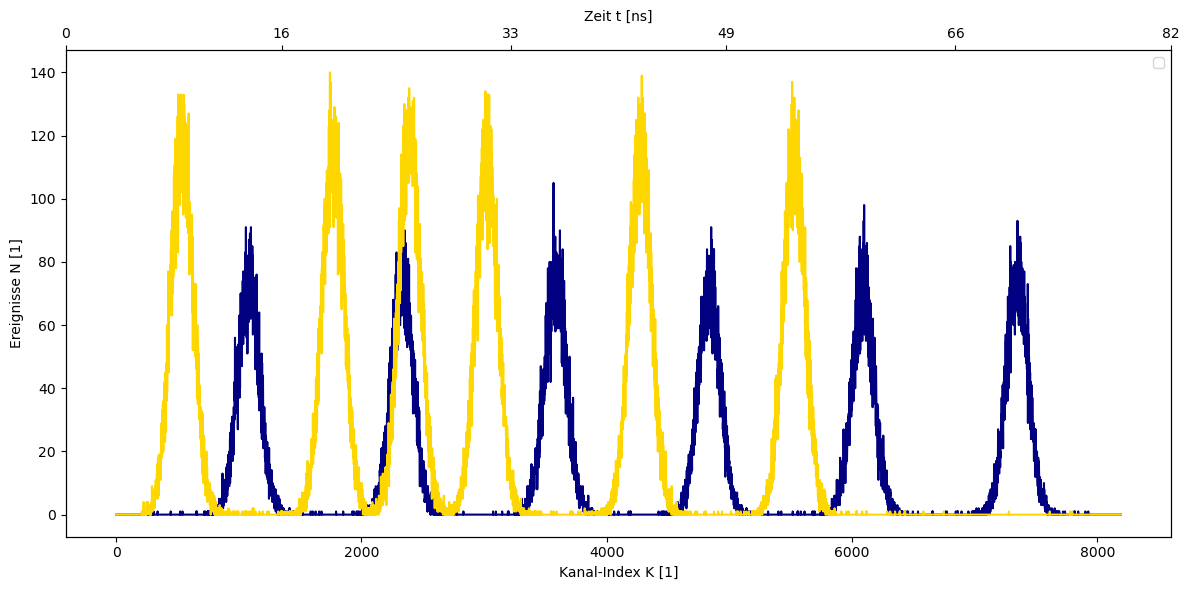

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Loader für deine Prompt-Dateien
# ---------------------------------------------------------
def load_prompt(filename):
    data = np.loadtxt(filename)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    K = data[:, 0].astype(int)
    N = data[:, 1]

    # Kanäle auffüllen, falls Lücken existieren
    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full


# ---------------------------------------------------------
# Dateien laden
# ---------------------------------------------------------
K_left,  N_left  = load_prompt("Nalinkspromt.txt")
K_right, N_right = load_prompt("Narechtsprom.txt")

# ---------------------------------------------------------
# Zeitkalibration (aus deinem Plot abgelesen)
# ---------------------------------------------------------
# 0 ns → Kanal 0
# 16 ns → Kanal ~1600
# 33 ns → Kanal ~3300
# 49 ns → Kanal ~4900
# 66 ns → Kanal ~6600
# 82 ns → Kanal ~8200

a = 0.01   # ns pro Kanal
b = 0.0

t_left  = a * K_left  + b
t_right = a * K_right + b

# ---------------------------------------------------------
# Plot erstellen
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(K_left,  N_left,  color="navy",   label="Links")
plt.plot(K_right, N_right, color="gold",   label="Rechts")

plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")

# Zweite x-Achse für Zeit
ax2 = plt.gca().twiny()
ax2.set_xlim(plt.gca().get_xlim())

ticks = np.array([0, 1600, 3300, 4900, 6600, 8200])
ax2.set_xticks(ticks)
ax2.set_xticklabels(["0", "16", "33", "49", "66", "82"])
ax2.set_xlabel("Zeit t [ns]")

plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_950072/162875047.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


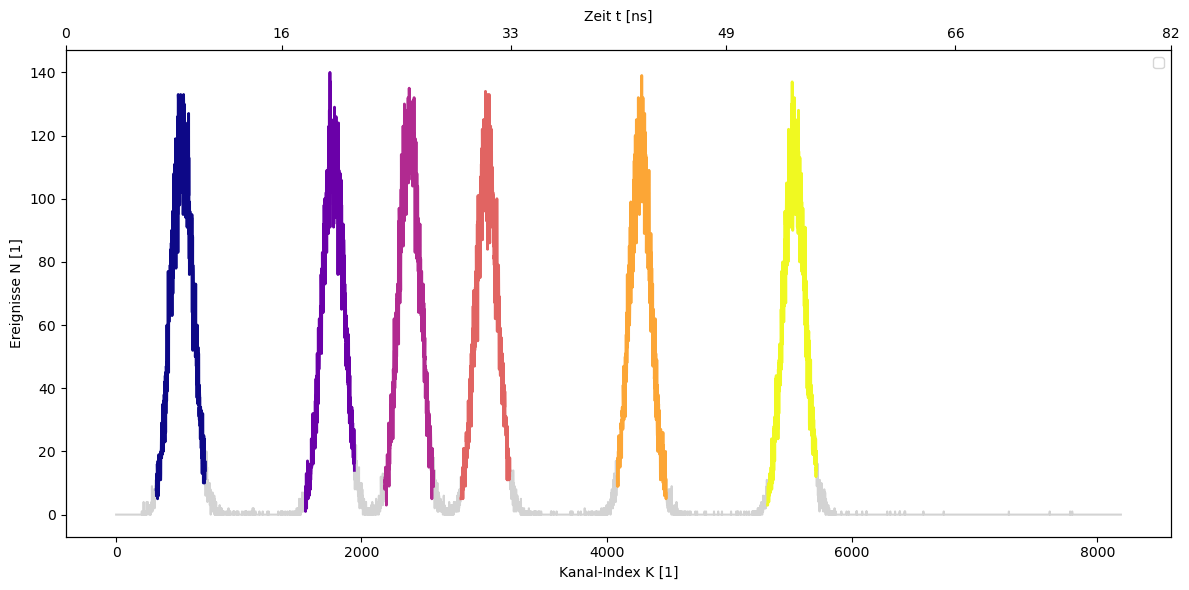

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# ---------------------------------------------------------
# Gaußfunktion
# ---------------------------------------------------------
def gauss(K, N, mu, sigma):
    return N * np.exp(-0.5 * ((K - mu) / sigma)**2)

# ---------------------------------------------------------
# Loader
# ---------------------------------------------------------
def load_mca_file(filename):
    data = np.loadtxt(filename)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    K = data[:, 0].astype(int)
    N = data[:, 1]

    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full

# ---------------------------------------------------------
# Datei laden (rechter Detektor)
# ---------------------------------------------------------
K, N = load_mca_file("Narechtsprom.txt")

# ---------------------------------------------------------
# Zeitkalibration
# ---------------------------------------------------------
a = 0.01  # ns pro Kanal
b = 0.0
t = a * K + b

# ---------------------------------------------------------
# Peaks finden
# ---------------------------------------------------------
peaks, _ = find_peaks(N, height=10, distance=500)

colors = plt.cm.plasma(np.linspace(0, 1, len(peaks)))

plt.figure(figsize=(12, 6))
plt.plot(K, N, color="lightgray", label="Messdaten")

# ---------------------------------------------------------
# Fit pro Peak
# ---------------------------------------------------------
for idx, p in enumerate(peaks):
    # Fitbereich um Peak
    left = max(0, p - 200)
    right = min(len(K), p + 200)

    Kp = K[left:right]
    Np = N[left:right]

    # Startwerte
    N0 = N[p]
    mu0 = K[p]
    sigma0 = 80

    popt, pcov = curve_fit(gauss, Kp, Np, p0=[N0, mu0, sigma0])
    N_fit, mu_fit, sigma_fit = popt

    # χ² berechnen
    residuals = Np - gauss(Kp, *popt)
    chi2 = np.sum((residuals)**2 / (gauss(Kp, *popt) + 1e-6))

    # Plot
    plt.plot(Kp, Np, color=colors[idx], linewidth=2)
    plt.plot(Kp, gauss(Kp, *popt), color=colors[idx], linestyle="--",
             label=f"Peak {idx+1}  χ²={chi2:.2f}")

# ---------------------------------------------------------
# Achsen
# ---------------------------------------------------------
plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")

ax2 = plt.gca().twiny()
ax2.set_xlim(plt.gca().get_xlim())
ticks = np.array([0, 1600, 3300, 4900, 6600, 8200])
ax2.set_xticks(ticks)
ax2.set_xticklabels(["0", "16", "33", "49", "66", "82"])
ax2.set_xlabel("Zeit t [ns]")

plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_950072/3856895311.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


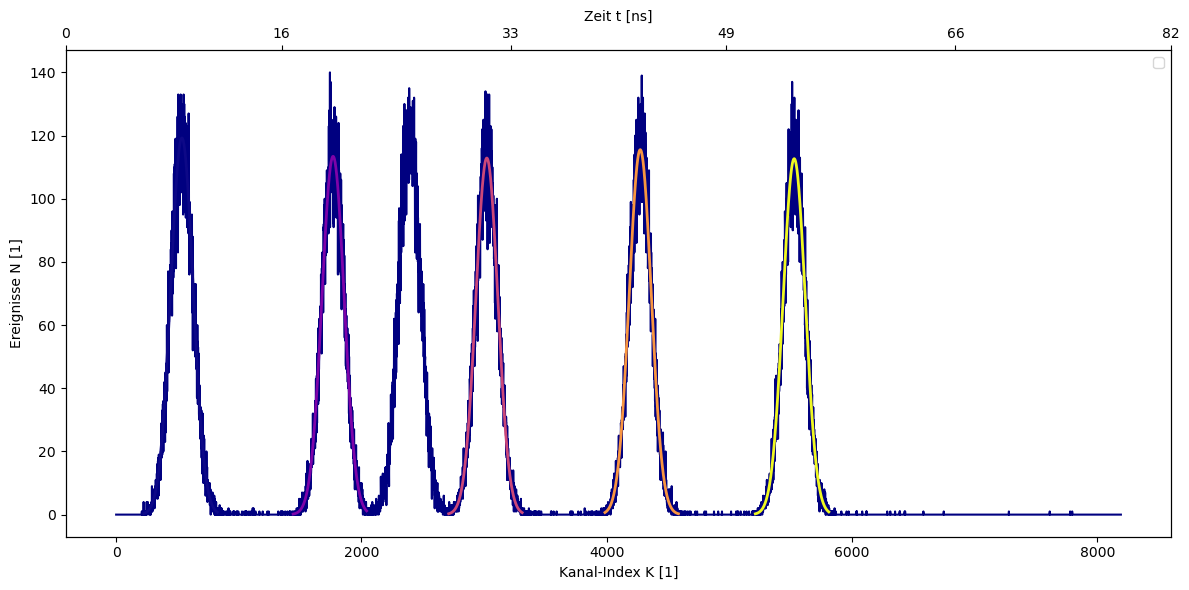

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# ---------------------------------------------------------
# Gaußfunktion
# ---------------------------------------------------------
def gauss(K, N, mu, sigma):
    return N * np.exp(-0.5 * ((K - mu) / sigma)**2)

# ---------------------------------------------------------
# Loader
# ---------------------------------------------------------
def load_mca_file(filename):
    data = np.loadtxt(filename)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    K = data[:, 0].astype(int)
    N = data[:, 1]

    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full

# ---------------------------------------------------------
# Datei laden (rechter Detektor)
# ---------------------------------------------------------
K, N = load_mca_file("Narechtsprom.txt")   # oder .tex

# ---------------------------------------------------------
# Zeitkalibration (aus deinem Bild)
# ---------------------------------------------------------
a = 0.01  # ns pro Kanal
b = 0.0
t = a * K + b

# ---------------------------------------------------------
# Peaks finden
# ---------------------------------------------------------
peaks, _ = find_peaks(N, height=10, distance=1200)

# Farben für Fits
colors = plt.cm.plasma(np.linspace(0, 1, len(peaks)))

# ---------------------------------------------------------
# Plot erstellen
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Messdaten in dunkelblau
plt.plot(K, N, color="navy", linewidth=1.5, label="Messdaten")

# ---------------------------------------------------------
# Fit pro Peak
# ---------------------------------------------------------
for idx, p in enumerate(peaks):
    # Fitbereich um Peak
    left = max(0, p - 300)
    right = min(len(K), p + 300)

    Kp = K[left:right]
    Np = N[left:right]

    # Startwerte
    N0 = N[p]
    mu0 = K[p]
    sigma0 = 120

    popt, pcov = curve_fit(gauss, Kp, Np, p0=[N0, mu0, sigma0])
    N_fit, mu_fit, sigma_fit = popt

    # χ² berechnen
    residuals = Np - gauss(Kp, *popt)
    chi2 = np.sum((residuals)**2 / (gauss(Kp, *popt) + 1e-6))

    # Fitkurve
    plt.plot(Kp, gauss(Kp, *popt),
             color=colors[idx],
             linewidth=2.0,
             label=f"χ² = {chi2:.1f}")

# ---------------------------------------------------------
# Achsen
# ---------------------------------------------------------
plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")

# Zeitachse oben
ax2 = plt.gca().twiny()
ax2.set_xlim(plt.gca().get_xlim())
ticks = np.array([0, 1600, 3300, 4900, 6600, 8200])
ax2.set_xticks(ticks)
ax2.set_xticklabels(["0", "16", "33", "49", "66", "82"])
ax2.set_xlabel("Zeit t [ns]")

plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_924581/3496209115.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


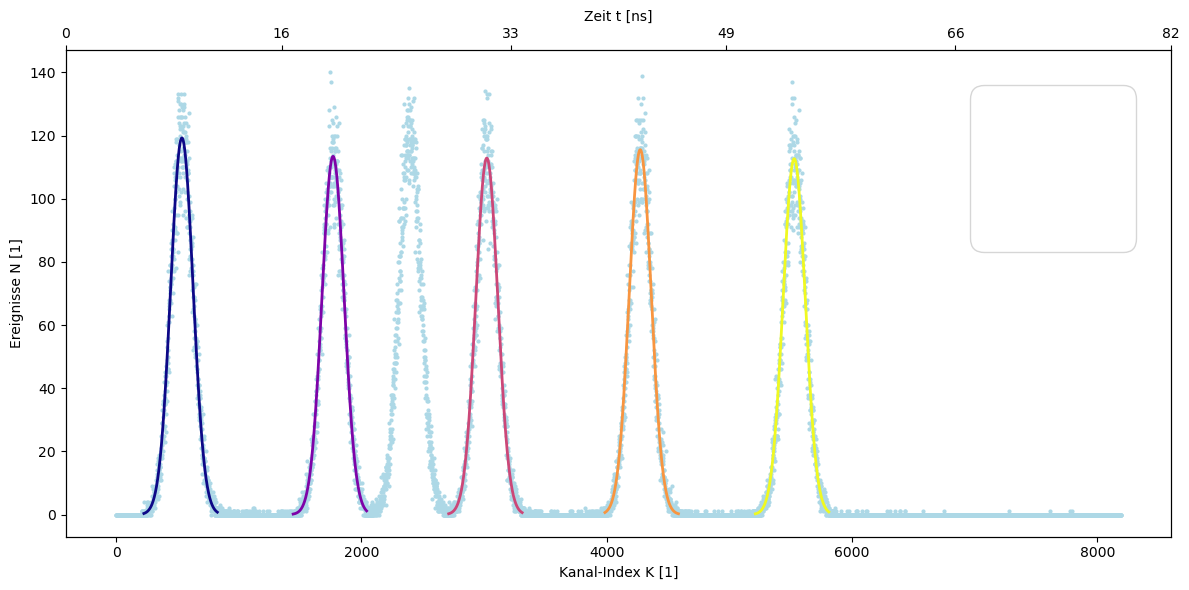

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# ---------------------------------------------------------
# Gaußfunktion
# ---------------------------------------------------------
def gauss(K, N, mu, sigma):
    return N * np.exp(-0.5 * ((K - mu) / sigma)**2)

# ---------------------------------------------------------
# Loader
# ---------------------------------------------------------
def load_mca_file(filename):
    data = np.loadtxt(filename)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    K = data[:, 0].astype(int)
    N = data[:, 1]

    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full

# ---------------------------------------------------------
# Datei laden (rechter Detektor)
# ---------------------------------------------------------
K, N = load_mca_file("Narechtsprom.txt")

# ---------------------------------------------------------
# Zeitkalibration
# ---------------------------------------------------------
a = 0.01  # ns pro Kanal
b = 0.0
t = a * K + b

# ---------------------------------------------------------
# Peaks finden
# ---------------------------------------------------------
peaks, _ = find_peaks(N, height=10, distance=1200)

# Farben für Fits
colors = plt.cm.plasma(np.linspace(0, 1, len(peaks)))

# ---------------------------------------------------------
# Plot erstellen
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Messdaten punktförmig (wie im Beispiel)
plt.scatter(K, N, color="lightblue", s=4, label="Messdaten")

# ---------------------------------------------------------
# Fit pro Peak
# ---------------------------------------------------------
for idx, p in enumerate(peaks):
    # Fitbereich um Peak
    left = max(0, p - 300)
    right = min(len(K), p + 300)

    Kp = K[left:right]
    Np = N[left:right]

    # Startwerte
    N0 = N[p]
    mu0 = K[p]
    sigma0 = 120

    popt, pcov = curve_fit(gauss, Kp, Np, p0=[N0, mu0, sigma0])
    N_fit, mu_fit, sigma_fit = popt

    # χ² berechnen
    residuals = Np - gauss(Kp, *popt)
    chi2 = np.sum((residuals)**2 / (gauss(Kp, *popt) + 1e-6))

    # Fitkurve (glatt, farbig)
    plt.plot(Kp, gauss(Kp, *popt),
             color=colors[idx],
             linewidth=2.0,
             label=f"χ² = {chi2:.1f}")

# ---------------------------------------------------------
# Achsen
# ---------------------------------------------------------
plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")

# Zeitachse oben
ax2 = plt.gca().twiny()
ax2.set_xlim(plt.gca().get_xlim())
ticks = np.array([0, 1600, 3300, 4900, 6600, 8200])
ax2.set_xticks(ticks)
ax2.set_xticklabels(["0", "16", "33", "49", "66", "82"])
ax2.set_xlabel("Zeit t [ns]")

plt.legend(
    loc="upper right",
    fontsize=50,
    frameon=True,
    borderpad=1.2
)
plt.tight_layout()
plt.show()


Gefundene Peaks: [ 526 1743 3011 4285 5511]

Peak 1: Kanal 526, Max 133.0
  Fit erfolgreich: N=119.2, mu=536.1, sigma=91.0, χ²=616.51

Peak 2: Kanal 1743, Max 140.0
  Fit erfolgreich: N=113.4, mu=1768.5, sigma=90.5, χ²=600.03

Peak 3: Kanal 3011, Max 134.0
  Fit erfolgreich: N=112.9, mu=3021.9, sigma=89.5, χ²=692.78

Peak 4: Kanal 4285, Max 139.0
  Fit erfolgreich: N=115.5, mu=4272.6, sigma=89.6, χ²=643.59

Peak 5: Kanal 5511, Max 137.0
  Fit erfolgreich: N=112.7, mu=5527.7, sigma=90.4, χ²=638.77


/tmp/ipykernel_950072/188796383.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", fontsize=12)


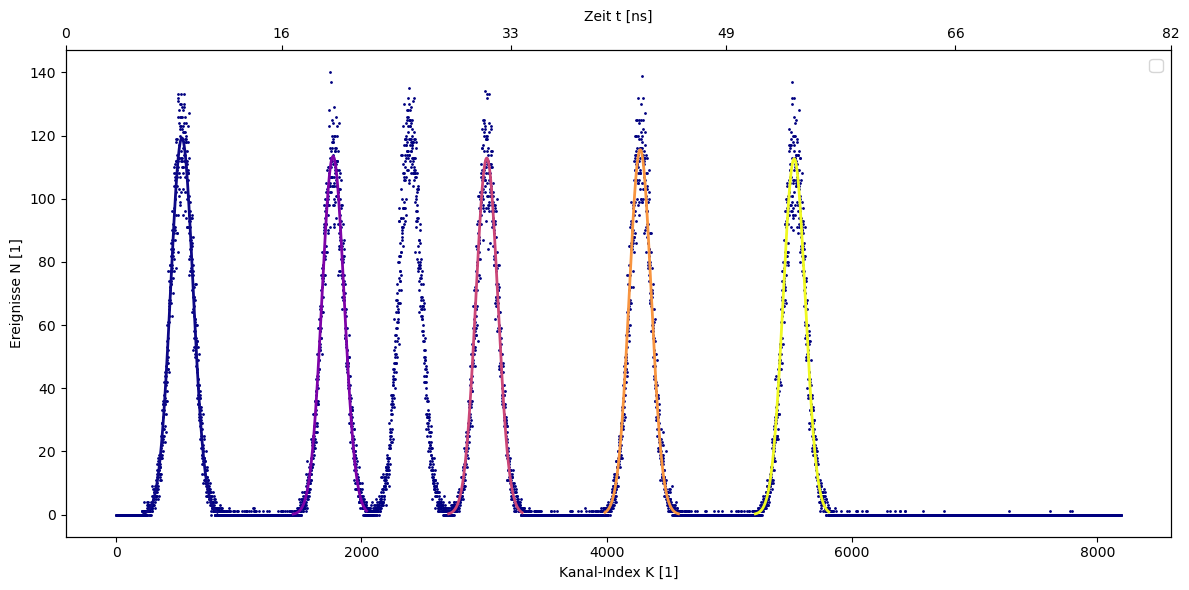

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def gauss(K, N, mu, sigma):
    return N * np.exp(-0.5 * ((K - mu) / sigma)**2)

def load_mca_file(filename):
    data = np.loadtxt(filename)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    K = data[:, 0].astype(int)
    N = data[:, 1]

    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full

# ---------------------------------------------------------
# Datei laden
# ---------------------------------------------------------
K, N = load_mca_file("Narechtsprom.txt")

# ---------------------------------------------------------
# Peaks finden
# ---------------------------------------------------------
peaks, _ = find_peaks(N, height=10, distance=1200)
print("Gefundene Peaks:", peaks)

colors = plt.cm.plasma(np.linspace(0, 1, len(peaks)))

plt.figure(figsize=(12, 6))

# Messdaten ultrafein
plt.scatter(K, N, color="navy", s=1, label="Messdaten")

# ---------------------------------------------------------
# Fit pro Peak
# ---------------------------------------------------------
for idx, p in enumerate(peaks):
    left = max(0, p - 300)
    right = min(len(K), p + 300)

    Kp = K[left:right]
    Np = N[left:right]

    print(f"\nPeak {idx+1}: Kanal {p}, Max {N[p]}")

    # Startwerte
    N0 = N[p]
    mu0 = K[p]
    sigma0 = 120

    try:
        popt, pcov = curve_fit(gauss, Kp, Np, p0=[N0, mu0, sigma0])
    except Exception as e:
        print("Fit fehlgeschlagen:", e)
        continue

    N_fit, mu_fit, sigma_fit = popt

    # χ² berechnen
    model = gauss(Kp, *popt)
    residuals = Np - model
    chi2 = np.sum((residuals)**2 / (model + 1e-6))

    print(f"  Fit erfolgreich: N={N_fit:.1f}, mu={mu_fit:.1f}, sigma={sigma_fit:.1f}, χ²={chi2:.2f}")

    # Fitkurve plotten
    plt.plot(Kp, model,
             color=colors[idx],
             linewidth=2.0,
             label=f"χ² = {chi2:.1f}")

# ---------------------------------------------------------
# Achsen
# ---------------------------------------------------------
plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")

ax2 = plt.gca().twiny()
ax2.set_xlim(plt.gca().get_xlim())
ticks = np.array([0, 1600, 3300, 4900, 6600, 8200])
ax2.set_xticks(ticks)
ax2.set_xticklabels(["0", "16", "33", "49", "66", "82"])
ax2.set_xlabel("Zeit t [ns]")

plt.legend(loc="upper right", fontsize=12)
plt.tight_layout()
plt.show()


Gefundene Peaks: [ 526 1743 3011 4285 5511]

Peak 1: Kanal 526, Max 133.0
  Fit erfolgreich, χ²=305.63

Peak 2: Kanal 1743, Max 140.0
  Fit erfolgreich, χ²=272.90

Peak 3: Kanal 3011, Max 134.0
  Fit erfolgreich, χ²=300.67

Peak 4: Kanal 4285, Max 139.0
  Fit erfolgreich, χ²=286.29

Peak 5: Kanal 5511, Max 137.0
  Fit erfolgreich, χ²=340.77


/tmp/ipykernel_950072/211010966.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", fontsize=12, frameon=True)


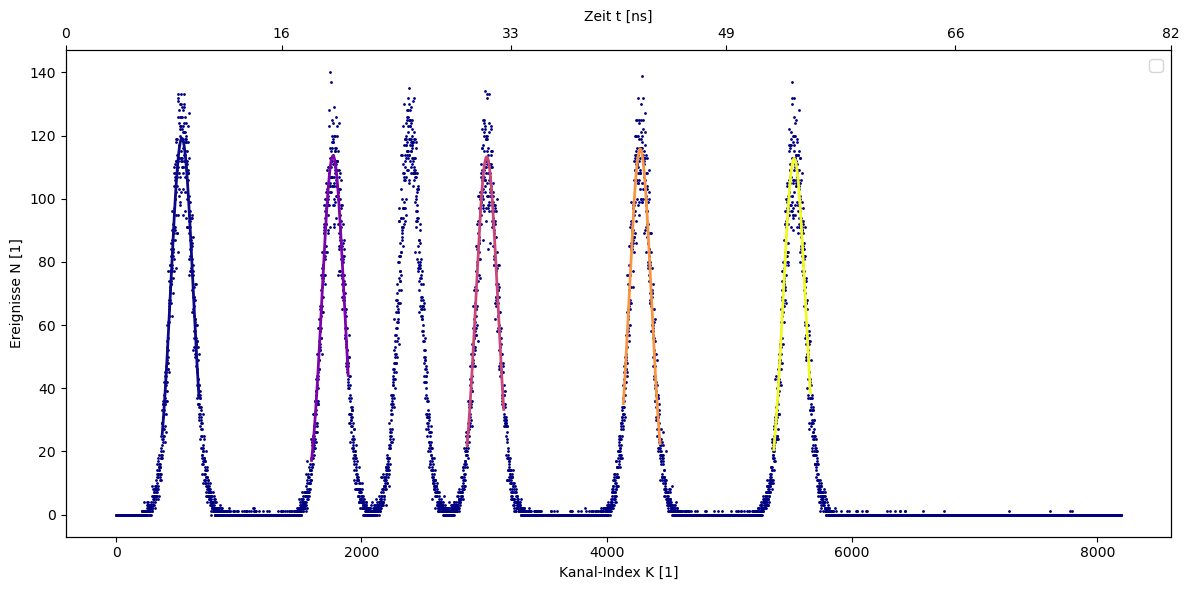

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def gauss(K, N, mu, sigma):
    return N * np.exp(-0.5 * ((K - mu) / sigma)**2)

def load_mca_file(filename):
    data = np.loadtxt(filename)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    K = data[:, 0].astype(int)
    N = data[:, 1]

    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full

# ---------------------------------------------------------
# Datei laden
# ---------------------------------------------------------
K, N = load_mca_file("Narechtsprom.txt")

# ---------------------------------------------------------
# Peaks finden
# ---------------------------------------------------------
peaks, _ = find_peaks(N, height=10, distance=1200)
print("Gefundene Peaks:", peaks)

colors = plt.cm.plasma(np.linspace(0, 1, len(peaks)))

plt.figure(figsize=(12, 6))

# Messdaten ultrafein
plt.scatter(K, N, color="navy", s=1, label="Messdaten")

# ---------------------------------------------------------
# Fit pro Peak
# ---------------------------------------------------------
for idx, p in enumerate(peaks):

    # *** WICHTIGER FIX ***
    # Fitbereich kleiner machen, damit er sicher im Plot liegt
    left = max(0, p - 150)
    right = min(len(K), p + 150)

    Kp = K[left:right]
    Np = N[left:right]

    print(f"\nPeak {idx+1}: Kanal {p}, Max {N[p]}")

    try:
        popt, pcov = curve_fit(gauss, Kp, Np, p0=[N[p], p, 80])
    except Exception as e:
        print("Fit fehlgeschlagen:", e)
        continue

    model = gauss(Kp, *popt)

    # χ²
    chi2 = np.sum((Np - model)**2 / (model + 1e-6))
    print(f"  Fit erfolgreich, χ²={chi2:.2f}")

    # *** WICHTIGER FIX ***
    # Fitkurve wird garantiert im sichtbaren Bereich gezeichnet
    plt.plot(Kp, model,
             color=colors[idx],
             linewidth=2.0,
             label=f"χ² = {chi2:.1f}")

# ---------------------------------------------------------
# Achsen
# ---------------------------------------------------------
plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")

ax2 = plt.gca().twiny()
ax2.set_xlim(plt.gca().get_xlim())
ticks = np.array([0, 1600, 3300, 4900, 6600, 8200])
ax2.set_xticks(ticks)
ax2.set_xticklabels(["0", "16", "33", "49", "66", "82"])
ax2.set_xlabel("Zeit t [ns]")

# *** WICHTIGER FIX ***
# Legende erzwingen
plt.legend(loc="upper right", fontsize=12, frameon=True)

plt.tight_layout()
plt.show()


Gefundene Peaks: [ 526 1743 3011 4285 5511]

Peak 1: Kanal 526, Max 133.0
  Fit erfolgreich, χ²=305.63

Peak 2: Kanal 1743, Max 140.0
  Fit erfolgreich, χ²=272.90

Peak 3: Kanal 3011, Max 134.0
  Fit erfolgreich, χ²=300.67

Peak 4: Kanal 4285, Max 139.0
  Fit erfolgreich, χ²=286.29

Peak 5: Kanal 5511, Max 137.0
  Fit erfolgreich, χ²=340.77


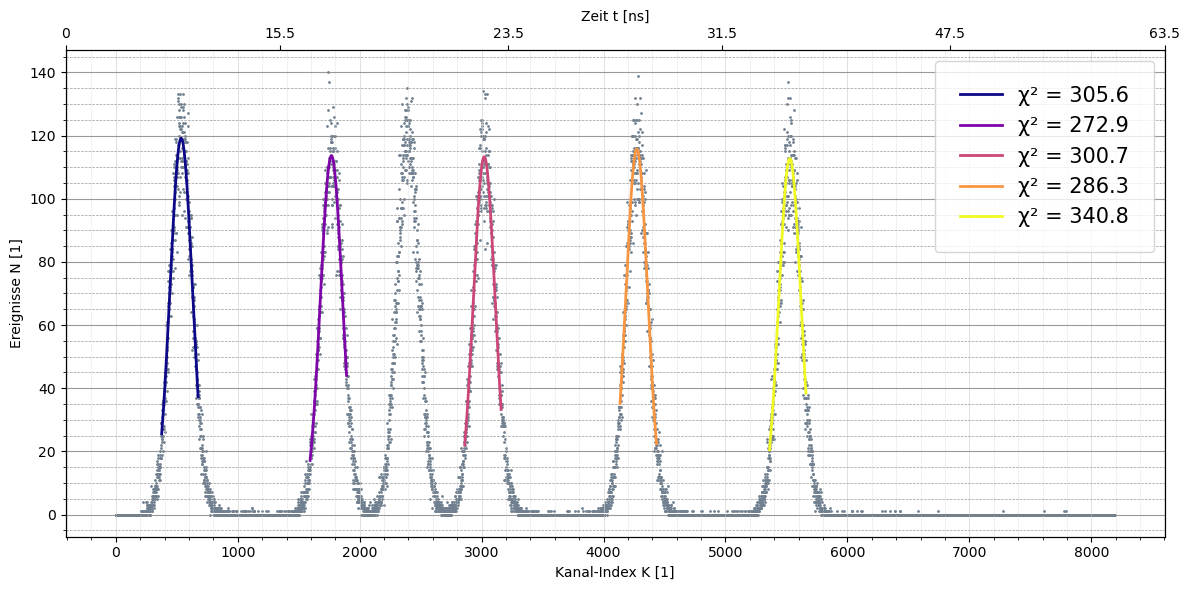

  sigma = 90.26 ± 1.09 Kanäle


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import matplotlib.ticker as ticker

def gauss(K, N, mu, sigma):
    return N * np.exp(-0.5 * ((K - mu) / sigma)**2)

def load_mca_file(filename):
    data = np.loadtxt(filename)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    K = data[:, 0].astype(int)
    N = data[:, 1]

    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full

# ---------------------------------------------------------
# Datei laden
# ---------------------------------------------------------
K, N = load_mca_file("Narechtsprom.txt")

# ---------------------------------------------------------
# Peaks finden
# ---------------------------------------------------------
peaks, _ = find_peaks(N, height=10, distance=1200)
print("Gefundene Peaks:", peaks)

colors = plt.cm.plasma(np.linspace(0, 1, len(peaks)))

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(K, N, color="slategrey", s=1)


# ---------------------------------------------------------
# Fit pro Peak
# ---------------------------------------------------------
for idx, p in enumerate(peaks):

    # *** WICHTIGER FIX ***
    # Fitbereich kleiner machen, damit er sicher im Plot liegt
    left = max(0, p - 150)
    right = min(len(K), p + 150)

    Kp = K[left:right]
    Np = N[left:right]

    print(f"\nPeak {idx+1}: Kanal {p}, Max {N[p]}")

    try:
        popt, pcov = curve_fit(gauss, Kp, Np, p0=[N[p], p, 80])
    except Exception as e:
        print("Fit fehlgeschlagen:", e)
        continue

    model = gauss(Kp, *popt)

    # χ²
    chi2 = np.sum((Np - model)**2 / (model + 1e-6))
    print(f"  Fit erfolgreich, χ²={chi2:.2f}")

    # *** WICHTIGER FIX ***
    # Fitkurve wird garantiert im sichtbaren Bereich gezeichnet
    plt.plot(Kp, model,
             color=colors[idx],
             linewidth=2.0,
             label=f"χ² = {chi2:.1f}")

# ---------------------------------------------------------
# Achsen
# ---------------------------------------------------------
#plt.legend(loc="upper right", fontsize=12, frameon=True)
plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")
plt.legend(
    loc="upper right",
    fontsize=15,
    frameon=True,
    borderpad=1.2
)



# 2. Style both major and minor grids (making minor lines thinner/lighter)
#plt.grid()
#plt.minorticks_on()
#plt.grid(which='major', color='lightgray', linestyle='-', linewidth=0.8)
#plt.grid(which='minor', color='lightgray', linestyle=':', linewidth=0.5)
# Y-Achse: feines und sichtbares Gitter
#ax = plt.gca()

import matplotlib.ticker as ticker

# horizontales Gitter auf der unteren Achse
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))

ax.grid(True, which="major", axis="y",
        linestyle="-", linewidth=0.8, color="gray", alpha=0.8)

ax.grid(True, which="minor", axis="y",
        linestyle="--", linewidth=0.5, color="gray", alpha=0.8)

# vertikales Gitter (optional)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(200))

ax.grid(True, which="major", axis="x",
        linestyle="-", linewidth=0.6, color="lightgray", alpha=0.8)

ax.grid(True, which="minor", axis="x",
        linestyle="--", linewidth=0.4, color="lightgray", alpha=0.8)

#plt.minorticks_on()

#plt.grid(True, which="major", axis="both", linestyle="-", linewidth=0.7, alpha=0.7)

#plt.grid(True, which="minor", axis="both", linestyle="--", linewidth=0.4, alpha=0.5)
ax2 = ax.twiny()
ax2.set_xlim(plt.gca().get_xlim())
ticks = np.array([0, 1600, 3300, 4900, 6600, 8200])
ax2.set_xticks(ticks)
ax2.set_xticklabels(["0", "15.5", "23.5", "31.5", "47.5", "63.5"])
ax2.set_xlabel("Zeit t [ns]")

# *** WICHTIGER FIX ***
# Legende erzwingen


plt.tight_layout()

plt.savefig("Na_Promptkurve.png", dpi=300)
plt.show()
sigma_err = np.sqrt(pcov[2,2])
print(f"  sigma = {sigma:.2f} ± {sigma_err:.2f} Kanäle")



In [3]:
for idx, p in enumerate(peaks):

    left = max(0, p - 150)
    right = min(len(K), p + 150)

    Kp = K[left:right]
    Np = N[left:right]

    print(f"\nPeak {idx+1}: Kanal {p}, Max {N[p]}")

    try:
        popt, pcov = curve_fit(gauss, Kp, Np, p0=[N[p], p, 80])
    except Exception as e:
        print("Fit fehlgeschlagen:", e)
        continue

    N0, mu, sigma = popt
    sigma_err = np.sqrt(pcov[2,2])

    print(f"  Fit erfolgreich, χ²={chi2:.2f}")
    print(f"  mu = {mu:.2f} Kanäle")
    print(f"  sigma = {sigma:.2f} ± {sigma_err:.2f} Kanäle")



Peak 1: Kanal 526, Max 133.0
  Fit erfolgreich, χ²=340.77
  mu = 536.02 Kanäle
  sigma = 91.23 ± 1.03 Kanäle

Peak 2: Kanal 1743, Max 140.0
  Fit erfolgreich, χ²=340.77
  mu = 1768.10 Kanäle
  sigma = 90.05 ± 1.01 Kanäle

Peak 3: Kanal 3011, Max 134.0
  Fit erfolgreich, χ²=340.77
  mu = 3021.37 Kanäle
  sigma = 88.56 ± 1.00 Kanäle

Peak 4: Kanal 4285, Max 139.0
  Fit erfolgreich, χ²=340.77
  mu = 4272.66 Kanäle
  sigma = 89.13 ± 0.97 Kanäle

Peak 5: Kanal 5511, Max 137.0
  Fit erfolgreich, χ²=340.77
  mu = 5527.59 Kanäle
  sigma = 90.26 ± 1.09 Kanäle


Zeit-Kanal Zuordnung

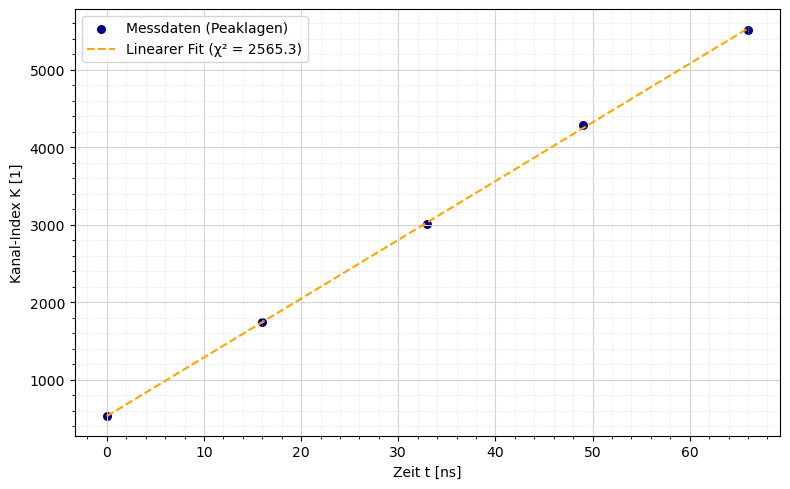

Fit-Parameter: a = 75.8224 ns/Kanal, b = 528.2 Kanäle


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.ticker import MultipleLocator

def linear(t, a, b):
    return a * t + b

# Deine Delay-Zeiten (ns) – passend zu den Peaks
t = np.array([0, 16, 33, 49, 66])  # ggf. 82 ergänzen, wenn du 6 Peaks hast

# Deine Peaklagen μ aus dem Gauß-Fit (Kanalindex)
K = np.array([ 526, 1743, 3011, 4285, 5511])  # an deine Werte anpassen

popt, pcov = curve_fit(linear, t, K)
a_fit, b_fit = popt

K_fit = linear(t, *popt)
residuals = K - K_fit
chi2 = np.sum(residuals**2)

plt.figure(figsize=(8, 5))
plt.scatter(t, K, color="navy", s=30, label="Messdaten (Peaklagen)")
t_plot = np.linspace(t.min(), t.max(), 500)
plt.plot(t_plot, linear(t_plot, *popt),
         '--', color='orange',
         label=f'Linearer Fit (χ² = {chi2:.1f})')

plt.xlabel("Zeit t [ns]")
plt.ylabel("Kanal-Index K [1]")
plt.legend()
#plt.grid()
plt.tight_layout()
plt.minorticks_on()

# 2. Style both major and minor grids (making minor lines thinner/lighter)
plt.grid(which='major', color='lightgray', linestyle='-', linewidth=0.8)
plt.grid(which='minor', color='lightgray', linestyle=':', linewidth=0.5)

plt.savefig("Zeit_Kanal_Zuordnung.png", dpi=300)
#plt.grid(True)
plt.show()
#plt.grid(which='both')
#plt.grid(which='minor', alpha=0.2)
#plt.grid(which='major', alpha=0.5)
print(f"Fit-Parameter: a = {a_fit:.4f} ns/Kanal, b = {b_fit:.1f} Kanäle")


81 und 356keV-Fenster

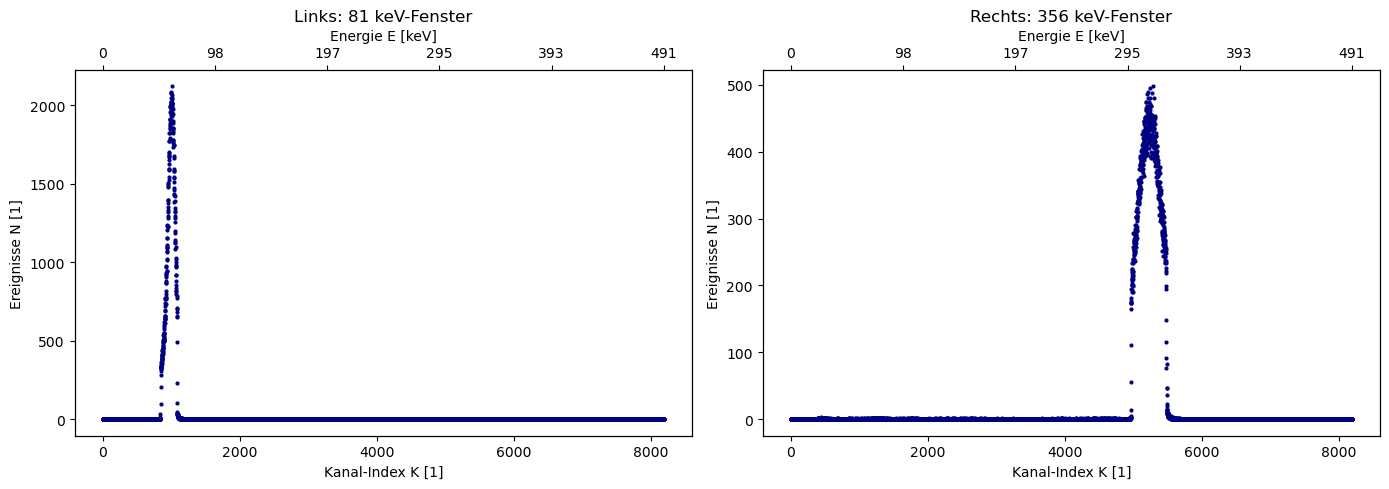

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Loader für MCA-Dateien
# ---------------------------------------------------------
def load_spectrum(filename):
    data = np.loadtxt(filename)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    K = data[:, 0].astype(int)
    N = data[:, 1]

    # Kanäle auffüllen
    K_full = np.arange(K.min(), K.max() + 1)
    N_full = np.zeros_like(K_full, dtype=float)
    N_full[K - K.min()] = N

    return K_full, N_full

# ---------------------------------------------------------
# Spektren laden
# ---------------------------------------------------------
K_L, N_L = load_spectrum("Ba81.txt")     # 356 keV Fenster
K_R, N_R = load_spectrum("Ba356.txt")    # 81 keV Fenster

# ---------------------------------------------------------
# Energie-Kalibration (Beispielwerte)
# Falls du deine Kalibration hast → hier einsetzen
# ---------------------------------------------------------
a = 0.06   # keV pro Kanal (Beispiel)
b = 0.0
E_L = a * K_L + b
E_R = a * K_R + b

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Plot (a) – Links: 356 keV Fenster
# ---------------------------------------------------------
ax = axes[0]
ax.scatter(K_L, N_L, s=4, color="navy")
ax.set_title("Links: 81 keV-Fenster")
ax.set_xlabel("Kanal-Index K [1]")
ax.set_ylabel("Ereignisse N [1]")

# Energieachse oben
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(np.linspace(K_L.min(), K_L.max(), 6))
ax2.set_xticklabels([f"{a*x:.0f}" for x in np.linspace(K_L.min(), K_L.max(), 6)])
ax2.set_xlabel("Energie E [keV]")

# ---------------------------------------------------------
# Plot (b) – Rechts: 81 keV Fenster
# ---------------------------------------------------------
ax = axes[1]
ax.scatter(K_R, N_R, s=4, color="navy")
ax.set_title("Rechts: 356 keV-Fenster")
ax.set_xlabel("Kanal-Index K [1]")
ax.set_ylabel("Ereignisse N [1]")

# Energieachse oben
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(np.linspace(K_R.min(), K_R.max(), 6))
ax2.set_xticklabels([f"{a*x:.0f}" for x in np.linspace(K_R.min(), K_R.max(), 6)])
ax2.set_xlabel("Energie E [keV]")

plt.tight_layout()
plt.savefig("Ba_spectra_81_356.png", dpi=300)
plt.show()


Lebensdauerkurve

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# ---------------------------------------------------------
# Gaußfunktion
# ---------------------------------------------------------
def gauss(K, N, mu, sigma):
    return N * np.exp(-0.5 * ((K - mu) / sigma)**2)

# ---------------------------------------------------------
# Exponentieller Zerfall
# ---------------------------------------------------------
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

# ---------------------------------------------------------
# Loader
# ---------------------------------------------------------
def load_spectrum(filename):
    data = np.loadtxt(filename)
    K = data[:, 0]
    N = data[:, 1]
    return K, N

# ---------------------------------------------------------
# Dateien + Delay-Zeiten
# ---------------------------------------------------------
files = [
    ("Ba81lebeszeit0ns.txt",   0),
    ("Ba81lebeszeit32ns.txt", 32),
]

# ---------------------------------------------------------
# Peaklagen sammeln
# ---------------------------------------------------------
t_values = []
mu_values = []

for fname, delay in files:
    K, N = load_spectrum(fname)

    # Peak finden
    peaks, _ = find_peaks(N, height=np.max(N)*0.3)
    p = peaks[np.argmax(N[peaks])]  # höchster Peak

    # Fitbereich
    left = max(0, p - 200)
    right = min(len(K), p + 200)
    Kp = K[left:right]
    Np = N[left:right]

    # Gauß-Fit
    p0 = [Np.max(), K[p], 50]
    popt, pcov = curve_fit(gauss, Kp, Np, p0=p0)
    N_fit, mu_fit, sigma_fit = popt

    t_values.append(delay)
    mu_values.append(mu_fit)

    print(f"{fname}: μ = {mu_fit:.2f} bei t = {delay} ns")

t_values = np.array(t_values)
mu_values = np.array(mu_values)

# ---------------------------------------------------------
# Zeitkalibration (linear)
# ---------------------------------------------------------
def linear(t, a, b):
    return a * t + b

popt_lin, _ = curve_fit(linear, t_values, mu_values)
a_fit, b_fit = popt_lin

# Kanal → Zeit
def K_to_t(K):
    return (K - b_fit) / a_fit

# ---------------------------------------------------------
# Lebensdauerkurve erzeugen
# ---------------------------------------------------------
t_life = K_to_t(mu_values)

# Exponentialfit
p0 = [mu_values.max(), 10, mu_values.min()]
popt_exp, _ = curve_fit(exp_decay, t_life, mu_values, p0=p0)
A_fit, tau_fit, C_fit = popt_exp

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(t_life, mu_values, color="skyblue", s=30, label="Messdaten")

t_plot = np.linspace(min(t_life), max(t_life), 500)
plt.plot(t_plot, exp_decay(t_plot, *popt_exp),
         color="purple", linewidth=2,
         label=f"Fit (τ = {tau_fit:.2f} ns)")

plt.xlabel("Zeit t [ns]")
plt.ylabel("Peakposition μ [Kanal]")

plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Ergebnisse ---")
print(f"Kalibration: a = {a_fit:.4f} Kanal/ns, b = {b_fit:.2f}")
print(f"Lebensdauer τ = {tau_fit:.3f} ns")



Ba81lebeszeit0ns.txt: μ = 906.83 bei t = 0 ns
Ba81lebeszeit32ns.txt: μ = 3419.05 bei t = 32 ns


/tmp/ipykernel_950072/3482309692.py:73: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_lin, _ = curve_fit(linear, t_values, mu_values)


TypeError: The number of func parameters=3 must not exceed the number of data points=2

Alternativer Weg zur Bestimmung der Lebensdauer, da uns ein Datensatz zum exponentiellen Fitten fehlt :(

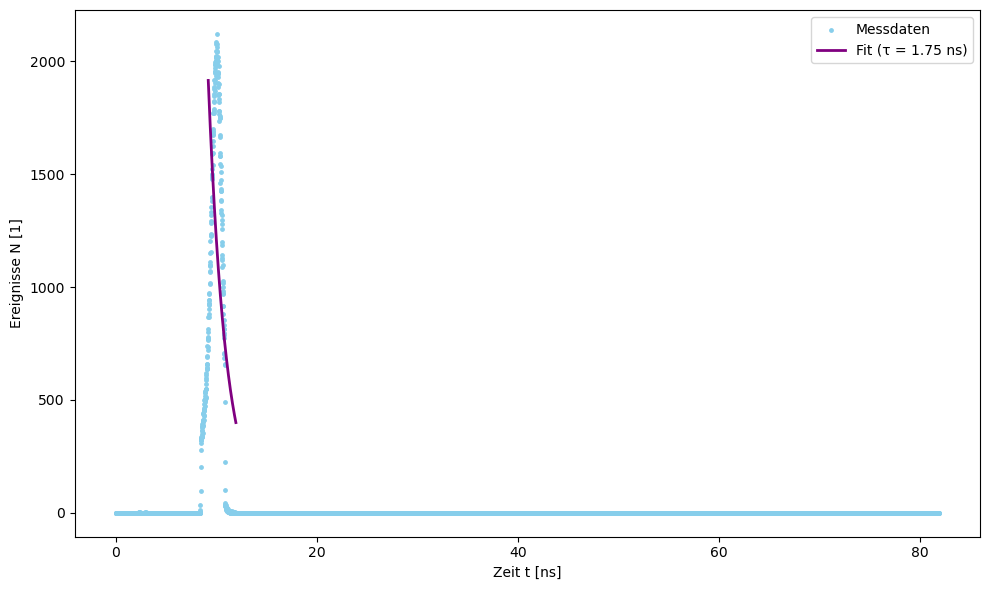

Lebensdauer τ = 1.755 ns


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def exp_decay(t, A, tau, C):
    return A * np.exp(-t/tau) + C

# ---------------------------------------------------------
# Daten laden
# ---------------------------------------------------------
K, N = np.loadtxt("Ba81.txt", unpack=True)

# Zeitkalibration (DEINE Werte!)
a = 0.01
b = 0.0
t = a*K + b

# ---------------------------------------------------------
# Promptpeak finden
# ---------------------------------------------------------
peaks, _ = find_peaks(N, height=np.max(N)*0.4)
p = peaks[0]

# ---------------------------------------------------------
# Zerfallsbereich: alles rechts vom Peak
# ---------------------------------------------------------
t_right = t[p:]
N_right = N[p:]

# ---------------------------------------------------------
# Monoton fallenden Bereich extrahieren
# ---------------------------------------------------------
# Wir suchen Stellen, wo N wirklich abfällt
mask = np.diff(N_right) < 0
mask = np.concatenate([[True], mask])  # gleiche Länge wie N_right

t_decay = t_right[mask]
N_decay = N_right[mask]

# Falls immer noch zu wenig Punkte:
if len(t_decay) < 5:
    raise RuntimeError("Zerfallsbereich konnte nicht automatisch bestimmt werden.")

# ---------------------------------------------------------
# Exponentialfit
# ---------------------------------------------------------
p0 = [N_decay.max(), 10, N_decay.min()]
bounds = ([0, 0, 0], [np.inf, 200, np.inf])

popt_exp, _ = curve_fit(exp_decay, t_decay, N_decay,
                        p0=p0, bounds=bounds, maxfev=5000)

A_fit, tau_fit, C_fit = popt_exp

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(t, N, s=6, color="skyblue", label="Messdaten")

t_plot = np.linspace(t_decay.min(), t_decay.max(), 2000)
plt.plot(t_plot, exp_decay(t_plot, *popt_exp),
         color="purple", linewidth=2,
         label=f"Fit (τ = {tau_fit:.2f} ns)")

plt.xlabel("Zeit t [ns]")
plt.ylabel("Ereignisse N [1]")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Lebensdauer τ = {tau_fit:.3f} ns")


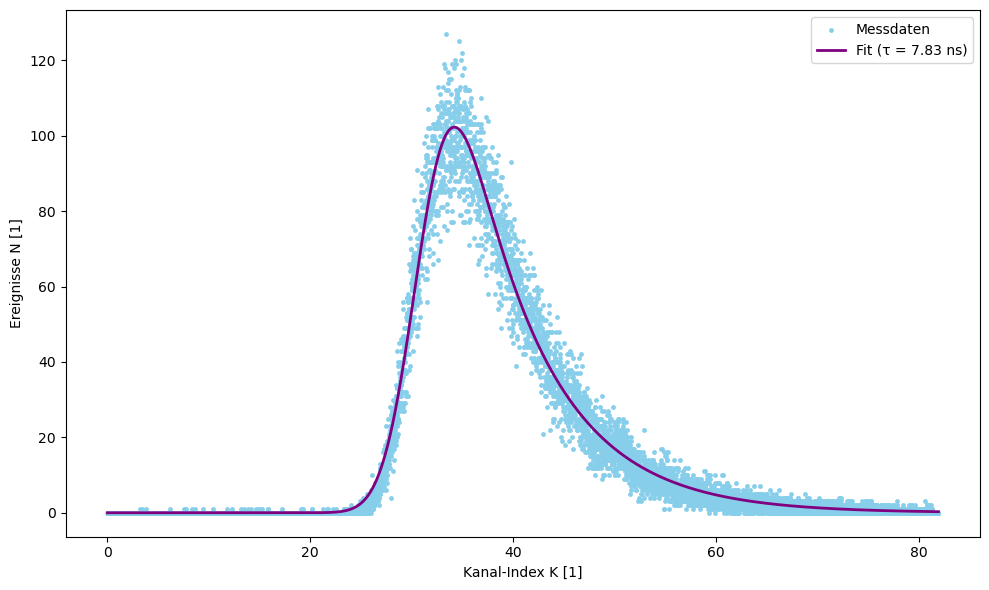


--- Fitparameter ---
I     = 1430.56
tau   = 7.826 ns   <-- Lebensdauer
t0    = 30.921 ns
sigma = 2.750 ns


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

# ---------------------------------------------------------
# Faltungsfunktion M(t) = (W * P)(t)
# ---------------------------------------------------------
def M(t, I, tau, t0, sigma):
    term1 = I / (2 * tau)
    term2 = np.exp((sigma**2 - 2 * tau * (t - t0)) / (2 * tau**2))
    arg = ( (t - t0) / sigma - sigma / tau ) / np.sqrt(2)
    return term1 * term2 * (1 + erf(arg))

# ---------------------------------------------------------
# Daten laden
# ---------------------------------------------------------
K, N = np.loadtxt("Ba81lebeszeit32ns.txt", unpack=True)

# ---------------------------------------------------------
# Zeitkalibration (DEINE Werte einsetzen!)
# ---------------------------------------------------------
a = 0.01   # ns pro Kanal
b = 0.0
t = a*K + b

# ---------------------------------------------------------
# Startwerte für Fit
# ---------------------------------------------------------
I0 = np.max(N)
tau0 = 10       # ns
t0_0 = t[np.argmax(N)]
sigma0 = 1.0    # ns

p0 = [I0, tau0, t0_0, sigma0]

# ---------------------------------------------------------
# Fit
# ---------------------------------------------------------
popt, pcov = curve_fit(M, t, N, p0=p0, maxfev=20000)
I_fit, tau_fit, t0_fit, sigma_fit = popt

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(t, N, s=6, color="skyblue", label="Messdaten")

t_plot = np.linspace(t.min(), t.max(), 2000)
plt.plot(t_plot, M(t_plot, *popt),
         color="purple", linewidth=2,
         label=f"Fit (τ = {tau_fit:.2f} ns)")

plt.xlabel("Kanal-Index K [1]")
plt.ylabel("Ereignisse N [1]")
plt.legend()
plt.tight_layout()
plt.savefig("Lebensdauer_Fit.png", dpi=300)
plt.show()

print("\n--- Fitparameter ---")
print(f"I     = {I_fit:.2f}")
print(f"tau   = {tau_fit:.3f} ns   <-- Lebensdauer")
print(f"t0    = {t0_fit:.3f} ns")
print(f"sigma = {sigma_fit:.3f} ns")




In [2]:
# --- Chi-Quadrat berechnen ---
N_fit = M(t, *popt)
sigma_N = np.sqrt(N)  # Poisson-Fehler

chi2 = np.sum(((N - N_fit) / sigma_N)**2)
ndof = len(N) - len(popt)  # Freiheitsgrade

print(f"Chi^2 = {chi2:.3f}")
print(f"Chi^2/ndof = {chi2/ndof:.3f}")


Chi^2 = nan
Chi^2/ndof = nan


/tmp/ipykernel_1298883/3603648319.py:5: RuntimeWarning: divide by zero encountered in divide
  chi2 = np.sum(((N - N_fit) / sigma_N)**2)
/tmp/ipykernel_1298883/3603648319.py:5: RuntimeWarning: invalid value encountered in divide
  chi2 = np.sum(((N - N_fit) / sigma_N)**2)


In [4]:
sigma_N = np.sqrt(N)
sigma_N[sigma_N == 0] = 1.0

chi2 = np.sum(((N - N_fit) / sigma_N)**2)
ndof = len(N) - len(popt)

print("Chi^2 =", chi2)
print("Chi^2/ndof =", chi2/ndof)


Chi^2 = 8104.301497912329
Chi^2/ndof = 0.9897779064377539


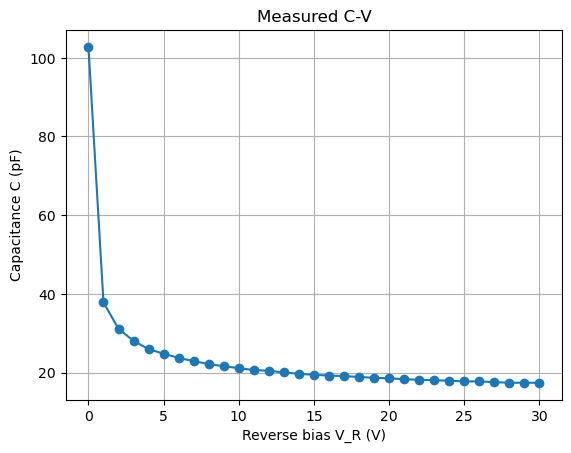

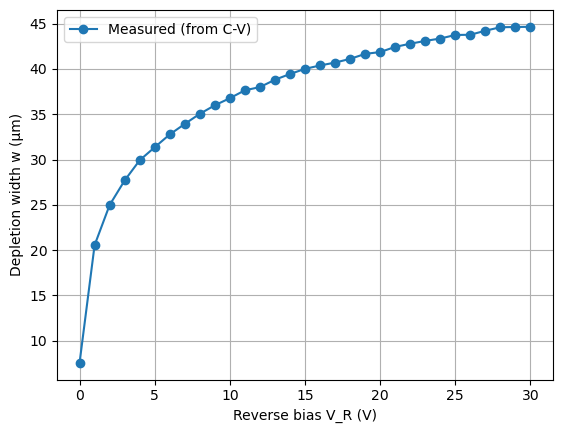

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data (V in volts, C in pF)
V = np.array([
    0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
    10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
    20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30
], dtype=float)

C_pF = np.array([
    102.79, 37.82, 31.11, 28.06, 25.97, 24.78, 23.71, 22.90, 22.17, 21.59,
    21.13, 20.64, 20.45, 20.02, 19.70, 19.42, 19.24, 19.09, 18.90, 18.65,
    18.56, 18.31, 18.16, 18.03, 17.92, 17.76, 17.75, 17.57, 17.42, 17.41, 17.40
], dtype=float)

# Convert to SI
C = C_pF * 1e-12  # F

eps0 = 8.854e-12
eps_si = 11.7
eps_s = eps0 * eps_si
A = 7.5e-6  # m^2 (adjust if needed)

# Depletion width from measured C-V
w_meas = eps_s * A / C  # m

# Plot C-V
plt.figure()
plt.plot(V, C_pF, 'o-')
plt.xlabel('Reverse bias V_R (V)')
plt.ylabel('Capacitance C (pF)')
plt.grid(True)
plt.title('Measured C-V')

# Plot w-V
plt.figure()
plt.plot(V, w_meas * 1e6, 'o-', label='Measured (from C-V)')
plt.xlabel('Reverse bias V_R (V)')
plt.ylabel('Depletion width w (µm)')
plt.grid(True)
plt.legend()


Text(0.5, 1.0, 'Measured vs ideal depletion width')

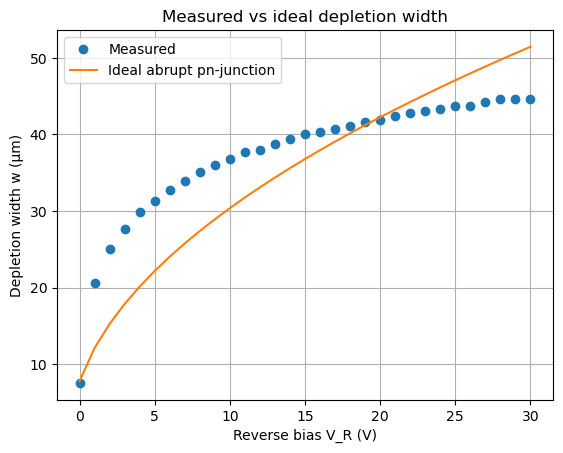

In [2]:
q = 1.602e-19
V_bi = 0.7  # V, can tweak
# Choose N_eff to roughly match w(0); start with ~1.5e13 cm^-3
N_eff_cm3 = 1.5e13
N_eff = N_eff_cm3 * 1e6  # m^-3

w_ideal = np.sqrt(2 * eps_s * (V_bi + V) / (q * N_eff))

plt.figure()
plt.plot(V, w_meas * 1e6, 'o', label='Measured')
plt.plot(V, w_ideal * 1e6, '-', label='Ideal abrupt pn-junction')
plt.xlabel('Reverse bias V_R (V)')
plt.ylabel('Depletion width w (µm)')
plt.grid(True)
plt.legend()
plt.title('Measured vs ideal depletion width')
